In [1]:
import os
os.getcwd()

'/kaggle/working'

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn

LR = 1e-3
EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [5]:
image, label = train_dataset[0]
print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


In [6]:
import math
NUM_BLOCKS = math.log2(28/4) # image size / target size
NUM_BLOCKS

2.807354922057604

In [22]:
class CNN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, num_classes):
        super().__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=32*1, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=32*2, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32*2, out_channels=32*4, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        flatten_size = 128 * 3 * 3
        self.full_connected_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layer(x)
        x = self.full_connected_layer(x)
        return x

In [23]:
model = CNN(in_channels=1, out_channels=32, kernel_size=3, padding=1, num_classes=NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [24]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE)

train_losses = []
test_accuracies = []
for epoch in range(EPOCHS):
    model.train()
    runningloss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        runningloss += loss.item()
    avg_loss = runningloss / len(train_loader)
    train_losses.append(avg_loss)    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
        
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum()
    acc = correct / total
    test_accuracies.append(acc)
    print(f"[{epoch + 1}] train loss : {avg_loss:.4f} test acc : {acc:.4f}")            

[1] train loss : 0.2238 test acc : 0.9857
[2] train loss : 0.0805 test acc : 0.9887
[3] train loss : 0.0572 test acc : 0.9912
[4] train loss : 0.0440 test acc : 0.9936
[5] train loss : 0.0359 test acc : 0.9921
[6] train loss : 0.0319 test acc : 0.9905
[7] train loss : 0.0273 test acc : 0.9931
[8] train loss : 0.0242 test acc : 0.9922
[9] train loss : 0.0208 test acc : 0.9908
[10] train loss : 0.0184 test acc : 0.9929
[11] train loss : 0.0189 test acc : 0.9941
[12] train loss : 0.0160 test acc : 0.9934
[13] train loss : 0.0147 test acc : 0.9947
[14] train loss : 0.0138 test acc : 0.9923
[15] train loss : 0.0160 test acc : 0.9937
[16] train loss : 0.0126 test acc : 0.9937
[17] train loss : 0.0126 test acc : 0.9928
[18] train loss : 0.0097 test acc : 0.9939
[19] train loss : 0.0124 test acc : 0.9939
[20] train loss : 0.0102 test acc : 0.9919
[21] train loss : 0.0112 test acc : 0.9928
[22] train loss : 0.0089 test acc : 0.9933
[23] train loss : 0.0109 test acc : 0.9932
[24] train loss : 0.

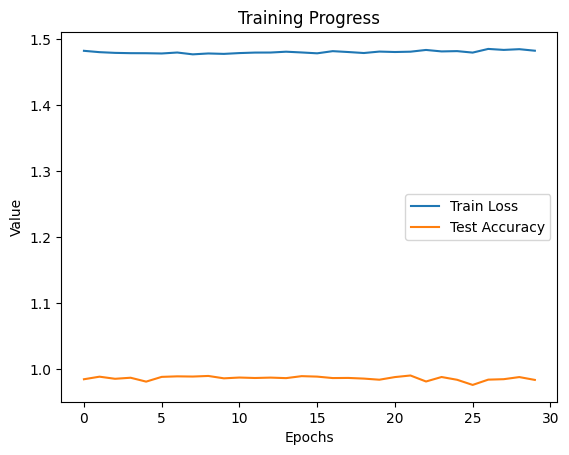

In [18]:
import matplotlib.pyplot as plt

epochs = list(range(EPOCHS))

fig, ax = plt.subplots()

ax.plot(epochs, train_losses, label="Train Loss")
ax.plot(epochs, [acc.to("cpu") for acc in test_accuracies], label="Test Accuracy")

ax.set_xlabel('Epochs')
ax.set_ylabel('Value')
ax.set_title('Training Progress')

ax.legend()

plt.show()

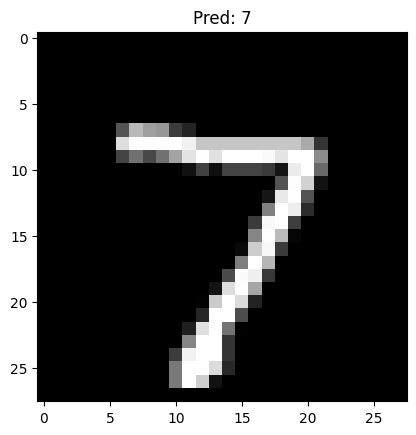

In [21]:
model.eval()
with torch.no_grad():
    images, labels = next(iter(test_loader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    plt.imshow(images[0].to("cpu").squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[0]}")
    plt.show()